In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from util import *
import os
from D3PM_function import *
from tauLDR_function import *
from SEDD_function import *
from discreteFM_function import *
from poisson_jump_function import *

# import importlib, SEDD_function
# importlib.reload(SEDD_function)
# from SEDD_function import *


from count_FM_function_v3 import *
from DirichletFM_function import *
from models import * 
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# Comparison Models:

1. D3PM (NeurIPS 2021)
2. tauLDR (tau-leaping denoising reversal)/ CTMC (NeurIPS 2022)
3. SEDD (ICML 2024)
4. disrete FM (NeurIPS 2024)
5. Dirichlet FM (ICML 2024)
6. Poisson jump (ICML 2023)
7. ours (count-FM)

# 1. Generate Data

In [2]:
np.random.seed(0)
N = 1000

# target
k    = np.array([[60.0, 5.0],  [60.0, 40.0]])   # shapes for comp 0 and 1 (2 dims)
rate = np.array([[1.0, 1.0],  [1.0, 1.0]])   # rates  for comp 0 and 1 (2 dims)
z = (np.random.rand(N) < 0.5).astype(int)    # 50/50 mixture labels
lam1 = np.random.gamma(shape=k[z], scale=1.0/rate[z])  # λ ~ 0.5*Gamma0 + 0.5*Gamma1
X1 = np.random.poisson(lam1)

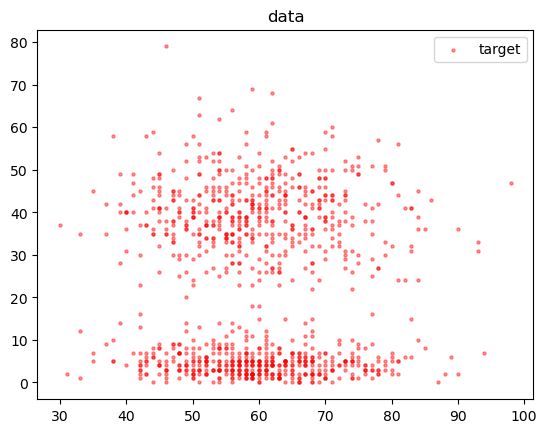

In [3]:
alpha_pt = 0.4
plt.scatter(X1[:,0], X1[:,1], c = 'r', s = 5, alpha = alpha_pt, label = 'target');
plt.title('data');
plt.legend();

# 2. Preperation

## 2.1 count FM

In [4]:
eps_t = 1e-4 # add some eps to avoid rate blow up for t = 1
eps_log = 1e-8 # for Poisson deviance...
lr = 1e-3
X1_torch = torch.tensor(X1)
N, d = X1_torch.shape

In [5]:
separate_heads = False
if not separate_heads:
    net_base = MLP(dim=d, out_dim=2*d, w=64, time_varying=True).to(device)
    net = MLP_rate(net_base)
    params = list(net.parameters())
    nets_countFM = net
    
if separate_heads:
    net_base_b = MLP(dim=d, out_dim=d, w=64, time_varying=True).to(device)  # births
    net_base_d = MLP(dim=d, out_dim=d, w=64, time_varying=True).to(device)  # deaths
    net_b = MLP_rate(net_base_b)
    net_d = MLP_rate(net_base_d)
    params = list(net_b.parameters()) + list(net_d.parameters())
    nets_countFM = [net_b, net_d]
    
opt_countFM = torch.optim.Adam(params, lr=lr)

## 2.2 Dirichlet FM

In [6]:
train_counts, C_max = build_count_dataset(X1, C_max=None, margin=2)
train_counts = train_counts.to(device)

# alpha_min, alpha_max, alpha_scale = suggest_alpha_hyper(C_max)
alpha_min, alpha_max, alpha_scale = 1.0, 100.0, 20.0 # defaul values in their code
print(alpha_min, alpha_max, alpha_scale)

1.0 100.0 20.0


In [7]:
condflow_counts = DirichletConditionalFlow(
    K=C_max + 1,
    alpha_min=alpha_min,
    alpha_max=alpha_max,
    alpha_spacing=0.01,   # same as repo
)

In [8]:
N, D = train_counts.shape
K = C_max + 1
classifier_DirFM = DirichletFMClassifier(num_dims=D, K=K, mlp_width=64, time_varying=True).to(device)
opt_DirFM = torch.optim.Adam(classifier_DirFM.parameters(), lr=lr)

## 2.3 D3PM

In [9]:
K = C_max + 1
classifier_D3PM = D3PMClassifier(num_dims=D, K=K, mlp_width=64, time_varying=True).to(device)
opt_D3PM = torch.optim.Adam(classifier_D3PM.parameters(), lr=lr)

## 2.4 tauLDR

In [10]:
classifier_tauLDR = TauLDRClassifier(dim=D, K=K, w=64, C_max=C_max).to(device)
opt_tauLDR = torch.optim.Adam(classifier_tauLDR.parameters(), lr=lr)

## 2.5 SEDD

In [11]:
K = C_max + 1
classifier_SEDD = SEDDUniformClassifier(dim=D, K=K, C_max=C_max, hidden=64, depth=3).to(device)
opt_SEDD = torch.optim.Adam(classifier_SEDD.parameters(), lr=lr)

## 2.6 discrete FM

In [12]:
N, D = train_counts.shape
K = C_max + 1

classifier_DisFM = DiscreteFMClassifier(num_dims=D, K=K, C_max=C_max, mlp_width=64).to(device)
opt_DisFM = torch.optim.Adam(classifier_DisFM.parameters(), lr=lr)

## 2.7 Poisson jump

In [41]:
decoder_PJUMP = PoissonJumpDecoder(dim=D, C_max=C_max, hidden=256, n_layers=2).to(device)
opt_PJUMP = torch.optim.Adam(decoder_PJUMP.parameters(), lr=1e-3)

# 3. Train

In [13]:
batch_size = 256
num_epochs = 10000

## 3.1 Count FM

In [14]:
loss_mode = 'poisson' # or 'poisson'/ 'l2'

In [15]:
nets_countFM, loss_countFM = CountFM_train(X1_torch, nets_countFM, opt_countFM, num_epochs, batch_size, device, separate_heads=separate_heads,
                                           x0_mode="uniform",  # "uniform", "poisson", or "dataset"
                                           C_max=C_max,
                                           eps_t=eps_t, eps_log=eps_log, loss_mode=loss_mode,
                                          )

  0%|                                                 | 0/10000 [00:00<?, ?it/s]/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/utils/_device.py:103: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return func(*args, **kwargs)
  0%|                                       | 22/10000 [00:00<01:20, 124.04it/s]

[CountFM][epoch 0] loss=-78.347687


 20%|███████▌                             | 2030/10000 [00:09<00:36, 219.77it/s]

[CountFM][epoch 2000] loss=-168.473785


 40%|██████████████▉                      | 4038/10000 [00:18<00:28, 207.92it/s]

...

 60%|██████████████████████▎              | 6038/10000 [00:28<00:18, 217.77it/s]

[CountFM][epoch 6000] loss=-143.480286


 80%|█████████████████████████████▋       | 8028/10000 [00:37<00:09, 218.84it/s]

[CountFM][epoch 8000] loss=-130.471588


100%|████████████████████████████████████| 10000/10000 [00:47<00:00, 211.83it/s]


## 3.2 Dirichlet FM

In [16]:
t_schedule = 'exp'

In [17]:
classifier_DirFM, loss_DirFM = DFM_train(train_counts, C_max, batch_size, num_epochs,
              classifier_DirFM, alpha_scale, alpha_min, alpha_max, t_schedule,
              opt_DirFM, device)

  0%|▏                                      | 40/10000 [00:00<00:48, 204.75it/s]

[DFM][epoch 0] loss=4.532314


 20%|███████▍                             | 2027/10000 [00:08<00:31, 251.88it/s]

[DFM][epoch 2000] loss=0.889577


 40%|██████████████▉                      | 4029/10000 [00:16<00:23, 254.40it/s]

...

 60%|██████████████████████▎              | 6047/10000 [00:24<00:15, 248.83it/s]

[DFM][epoch 6000] loss=0.760306


 80%|█████████████████████████████▊       | 8047/10000 [00:32<00:07, 249.68it/s]

[DFM][epoch 8000] loss=0.645647


100%|████████████████████████████████████| 10000/10000 [00:40<00:00, 249.41it/s]


## 3.3 D3PM

In [18]:
n_step = 1000
classifier_D3PM, loss_D3PM = D3PM_train(
    train_counts, C_max, batch_size, num_epochs,
    classifier_D3PM, opt_D3PM, device,
    num_steps=n_step,
    schedule="cosine",
    lambda_aux=1e-3,
)

100%|████████████████████████████████████| 10000/10000 [00:18<00:00, 552.18it/s]


## 3.4 tauLDR

In [19]:
classifier_tauLDR, loss_tauLDR = tauldr_train(
    train_counts=train_counts,
    C_max=C_max,
    batch_size=batch_size,
    num_epochs=num_epochs,
    classifier=classifier_tauLDR,
    opt=opt_tauLDR,
    device=device,
    schedule="exp",      # tauLDR-style exp schedule
    t_min=1e-3,
)

/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
100%|████████████████████████████████████| 10000/10000 [01:21<00:00, 122.74it/s]


## 3.5 SEDD

In [20]:
classifier_SEDD, loss_SEDD = sedd_train(
    train_counts=train_counts,
    C_max=C_max,
    batch_size=batch_size,
    num_epochs=num_epochs,
    classifier=classifier_SEDD,
    opt=opt_SEDD,
    device=device,
    schedule="loglinear",     # paper schedule option
    eps=1e-3,
    log_every=200,
)

[SEDD]: 100%|█████████████████| 10000/10000 [00:14<00:00, 682.30it/s, loss=8.72]


## 3.6 discrete FM

In [21]:
classifier_DisFM, loss_DisFM = discrete_fm_train(
    train_counts=train_counts,
    C_max=C_max,
    batch_size=batch_size,
    num_epochs=num_epochs,
    classifier=classifier_DisFM,
    opt=opt_DisFM,
    device=device,
    schedule="quadratic",   # DFM default-style choice
    t_min=1e-3,
    x0_mode="uniform",
)

[DiscreteFM]: 100%|███████████| 10000/10000 [00:11<00:00, 842.88it/s, loss=3.45]


## 3.7 Poisson jump

In [42]:
decoder_PJUMP, loss_PJUMP = pjump_train(
    train_counts=train_counts,
    C_max=C_max,
    batch_size=batch_size,
    num_epochs=num_epochs,
    decoder=decoder_PJUMP,
    opt=opt_PJUMP,
    device=device,
    n_step=n_step,
    schedule="exp",
    alpha_end=1e-3,
    lambda_scale=1.0,
)

[PoissonJUMP]: 100%|██████████| 10000/10000 [00:11<00:00, 845.98it/s, loss=3.02]


# 4. Generation

In [22]:
np.random.seed(123)
N_new = 1000
n_step = 1000
dist0 = torch.distributions.Dirichlet(torch.ones(K, device=device))
x = dist0.rsample((N_new, D))     # [B,D,K]
x0_prob = x / x.sum(-1, keepdim=True)

x0_new = x0_prob.argmax(-1).cpu()
x0_new_torch = torch.tensor(x0_new)

## 4.1 Binomial bridge

In [23]:
x1_countFM, traj_countFM = sample_euler(nets_countFM, n_step, x0_new_torch, device, eps_t, eps_log, separate_heads)
x1_countFM_np = x1_countFM.detach().cpu().numpy()
traj_countFM_np = traj_countFM.detach().cpu().numpy()

## 4.2 Dirichlet bridge

In [24]:
X1_DirFM, traj_DirFM = sample_dfm_counts(
    classifier=classifier_DirFM,
    condflow=condflow_counts,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    num_steps=n_step,
    alpha_min=alpha_min,
    alpha_max=alpha_max,
    device=device,
    return_traj=True,
    x0 = x0_prob
)

/home/ganchao/Desktop/count_FM/DirichletFM/utils/flow_utils.py:136: RuntimeWarning: divide by zero encountered in divide
  out = np.where((bs ** (alpha - 1)) > 0, out2 / (bs ** (alpha - 1)), 0)


## 4.3 D3PM

In [25]:
X1_D3PM, traj_D3PM = sample_d3pm_counts(
    classifier=classifier_D3PM,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    num_steps=n_step,
    device=device,
    xT=x0_new_torch.to(device).long(),
    return_traj=True,
)
X1_D3PM_np = X1_D3PM.detach().cpu().numpy()

## 4.4 tauLDR

In [26]:
x1_tauLDR, traj_tauLDR = tauldr_sample(
    classifier=classifier_tauLDR,
    n_step=n_step,
    x_noise=x0_new_torch,    # your uniform noise init
    C_max=C_max,
    device=device,
    schedule="exp",
    t_min=1e-3,
    return_traj=True,
)

In [27]:
x1_tauLDR_np = x1_tauLDR.detach().cpu().numpy()
traj_tauLDR_np = traj_tauLDR.detach().cpu().numpy()

In [28]:
x1_tauLDR_np.shape

(1000, 2)

## 4.5 SEDD

In [29]:
N_new = 1000
n_step = 1000
X1_SEDD, traj_SEDD = sample_sedd_uniform(
    classifier=classifier_SEDD,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    num_steps=n_step,
    device=device,
    schedule="loglinear",
    eps=1e-3,
    return_traj=True,
)
X1_SEDD_np = X1_SEDD.detach().cpu().numpy()
traj_SEDD_np = traj_SEDD.detach().cpu().numpy()

## 4.6 discrete FM

In [30]:
X1_DisFM, traj_DisFM = sample_discrete_fm(
    classifier=classifier_DisFM,
    x0=x0_new_torch,        # reuse your exact x0 for fair comparisons
    C_max=C_max,
    num_steps=n_step,
    device=device,
    schedule="quadratic",
    t_min=1e-3,
    return_traj=True,
)

In [31]:
X1_DisFM_np = X1_DisFM.detach().cpu().numpy()
traj_DisFM_np = traj_DisFM.detach().cpu().numpy()

## 4.7 Poisson jump

In [43]:
X1_PJUMP, traj_PJUMP = pjump_sample_counts(
    decoder=decoder_PJUMP,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    n_step=n_step,
    device=device,
    schedule="exp",
    alpha_end=1e-3,
    lambda_scale=1.0,
    return_traj=True,
)

In [44]:
X1_PJUMP_np = X1_PJUMP.detach().cpu().numpy()
traj_PJUMP_np = traj_PJUMP.detach().cpu().numpy()

# 5. Plot

## 5.1 Generated samples

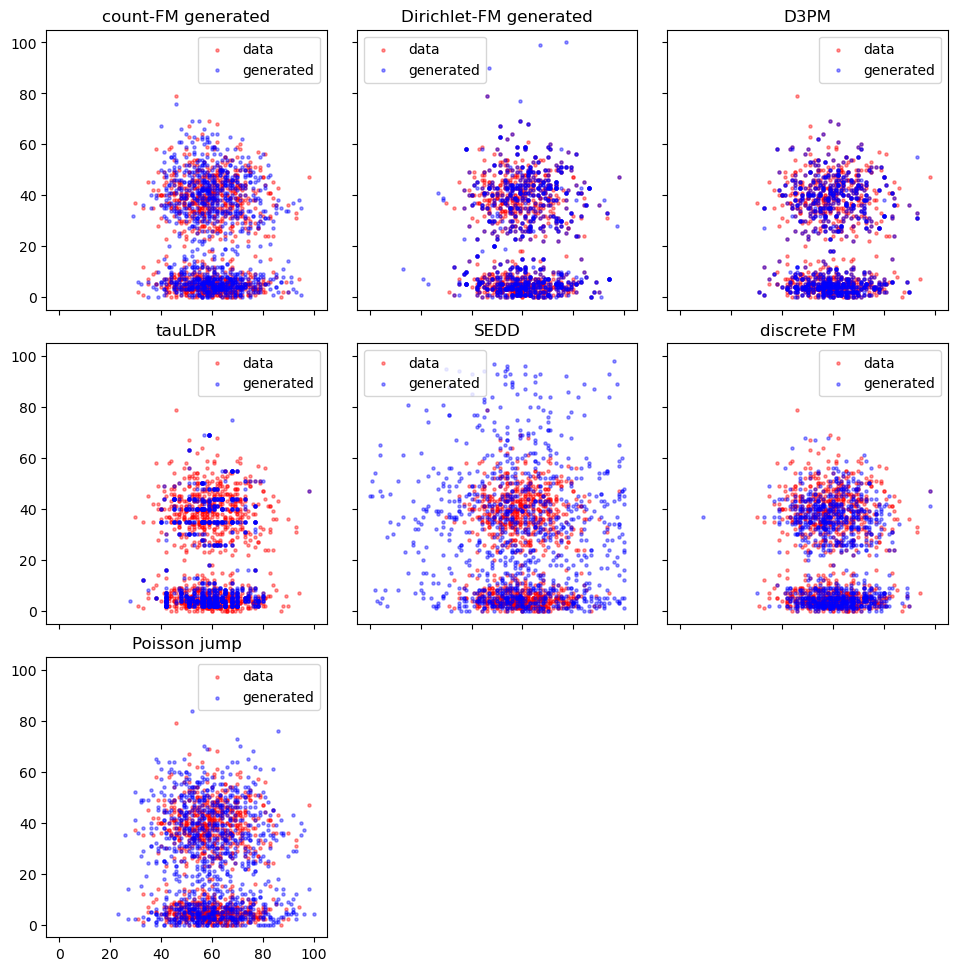

In [45]:
k = 7

ncols = int(np.ceil(np.sqrt(k)))
nrows = int(np.ceil(k / ncols))

side = 3.2  # inches per subplot side (tune)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(side * ncols, side * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
axes = np.ravel(axes)

axes[0].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[0].scatter(x1_countFM_np[:,0], x1_countFM_np[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[0].set_title('count-FM generated')
axes[0].legend(loc="best")

axes[1].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[1].scatter(X1_DirFM[:,0], X1_DirFM[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[1].set_title('Dirichlet-FM generated')
axes[1].legend(loc="best")

axes[2].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[2].scatter(X1_D3PM_np[:,0], X1_D3PM_np[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[2].set_title('D3PM')
axes[2].legend(loc="best")

axes[3].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[3].scatter(x1_tauLDR_np[:,0], x1_tauLDR_np[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[3].set_title('tauLDR')
axes[3].legend(loc="best")

axes[4].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[4].scatter(X1_SEDD_np[:,0], X1_SEDD_np[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[4].set_title('SEDD')
axes[4].legend(loc="best")

axes[5].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[5].scatter(X1_DisFM_np[:,0], X1_DisFM_np[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[5].set_title('discrete FM')
axes[5].legend(loc="best")

axes[6].scatter(X1[:,0], X1[:,1], c='r', s=5, alpha=alpha_pt, label='data')
axes[6].scatter(X1_PJUMP_np[:,0], X1_PJUMP_np[:,1], c='b', s=5, alpha=alpha_pt, label='generated')
axes[6].set_title('Poisson jump')
axes[6].legend(loc="best")

for ax in axes[:k]:
    ax.set_aspect("equal", adjustable="box")

for ax in axes[k:]:
    ax.set_visible(False)

plt.show()

## 5.2 Generated trajectories
Let's just show snapshots (although count-FM is easy to show the whole trajectories)...

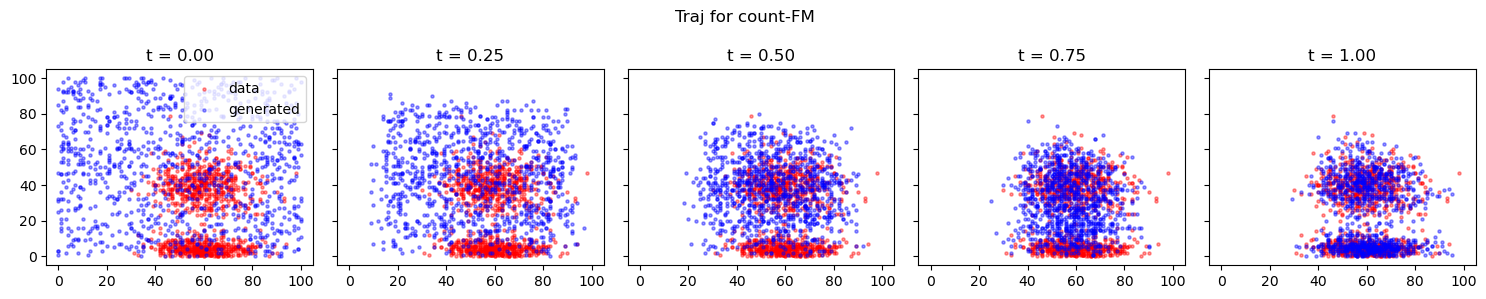

In [34]:
k = 5  # number of snapshots
T = traj_countFM_np.shape[0] - 1  # last valid time index (here 1000)
snapshot_ids = np.linspace(0, T, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)

for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1], c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_countFM_np[t_idx, :, 0],
               traj_countFM_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated')
    t_normalized = t_idx / T  # in [0, 1]
    ax.set_title(f"t = {t_normalized:.2f}")

    if j == 0:
        ax.legend(loc="best")

plt.suptitle('Traj for count-FM')
plt.tight_layout()
plt.show()

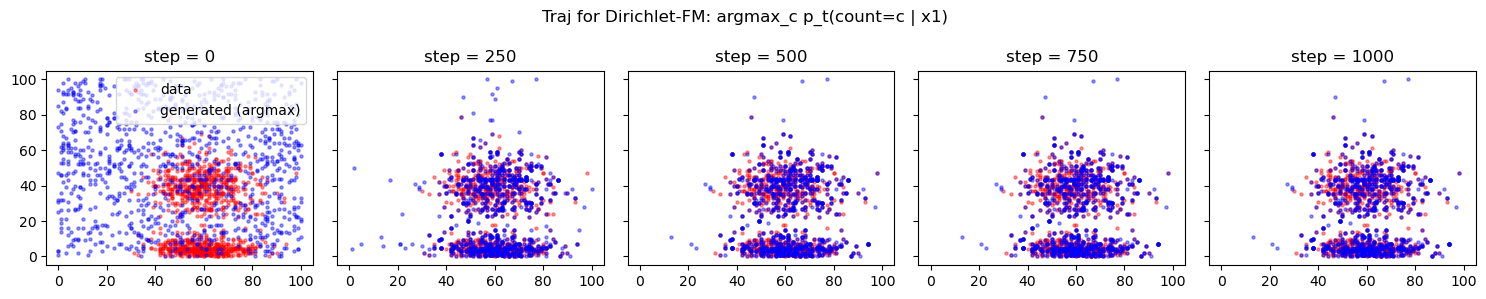

In [35]:
traj_DirFM_np = traj_DirFM.cpu().numpy()
traj_DirFM_counts_np = traj_DirFM_np.argmax(axis=-1)   # [T+1, B, D]

k = 5  # number of snapshots
T = traj_DirFM_counts_np.shape[0] - 1  # last valid time index
snapshot_ids = np.linspace(0, T, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)

for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1],
               c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_DirFM_counts_np[t_idx, :, 0],
               traj_DirFM_counts_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated (argmax)')
    ax.set_title(f"step = {t_idx}")

    if j == 0:
        ax.legend(loc="best")

plt.suptitle("Traj for Dirichlet-FM: argmax_c p_t(count=c | x1)")
plt.tight_layout()
plt.show()

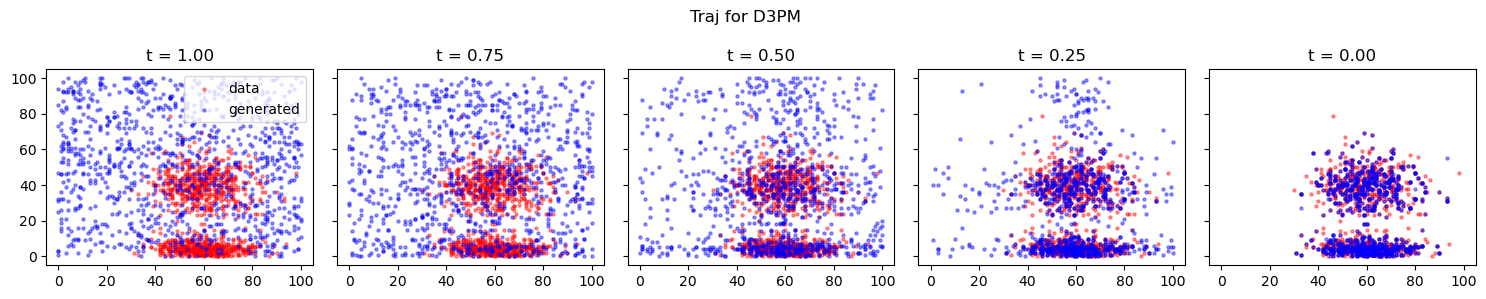

In [36]:
traj_D3PM_np = traj_D3PM.detach().cpu().numpy()   # [T+1, B, D]

k = 5  # number of snapshots
T = traj_D3PM_np.shape[0] - 1
snapshot_ids = np.linspace(T, 0, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)

for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1], c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_D3PM_np[t_idx, :, 0],
               traj_D3PM_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated')
    t_normalized = t_idx / T
    ax.set_title(f"t = {t_normalized:.2f}")

    if j == 0:
        ax.legend(loc="best")

plt.suptitle("Traj for D3PM")
plt.tight_layout()
plt.show()

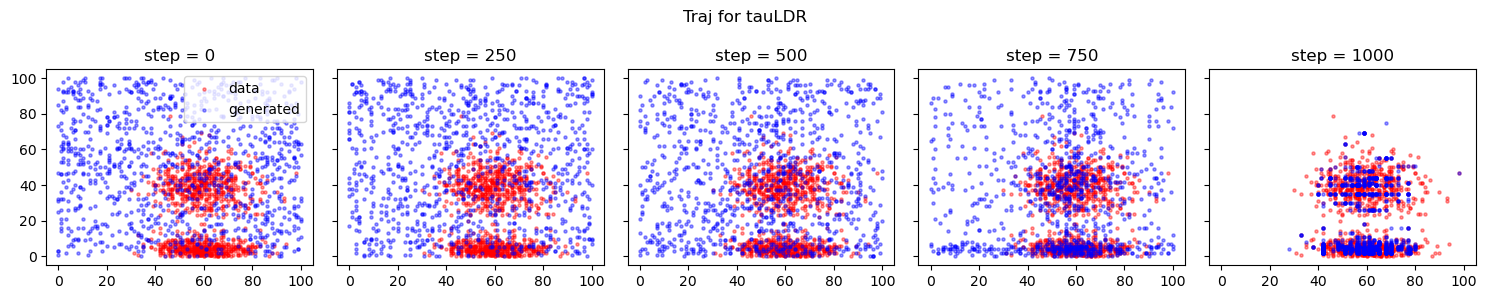

In [37]:
k = 5
T = traj_tauLDR_np.shape[0] - 1
snapshot_ids = np.linspace(0, T, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)

for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1], c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_tauLDR_np[t_idx, :, 0],
               traj_tauLDR_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated')
    ax.set_title(f"step = {t_idx}")
    if j == 0:
        ax.legend(loc="best")

plt.suptitle("Traj for tauLDR")
plt.tight_layout()
plt.show()

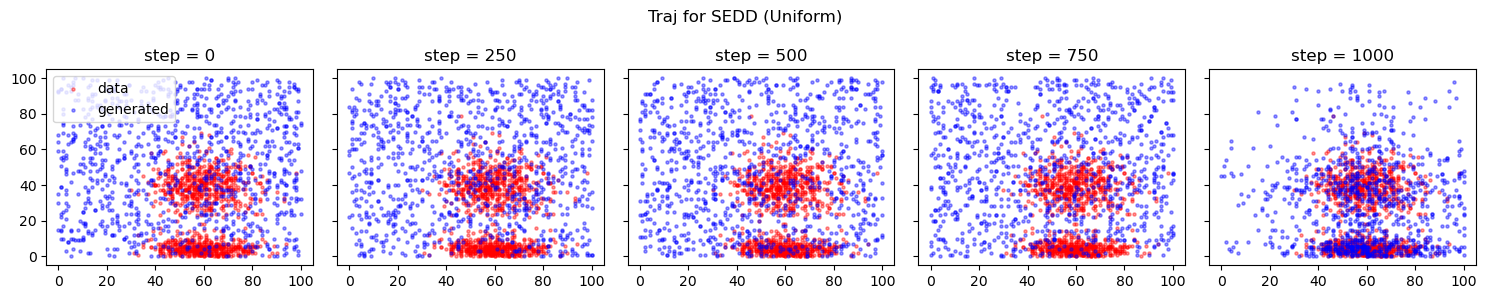

In [38]:
k = 5
T = traj_SEDD_np.shape[0] - 1
snapshot_ids = np.linspace(0, T, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)
for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1], c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_SEDD_np[t_idx, :, 0], traj_SEDD_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated')
    ax.set_title(f"step = {t_idx}")
    if j == 0:
        ax.legend(loc="best")
plt.suptitle("Traj for SEDD (Uniform)")
plt.tight_layout()
plt.show()


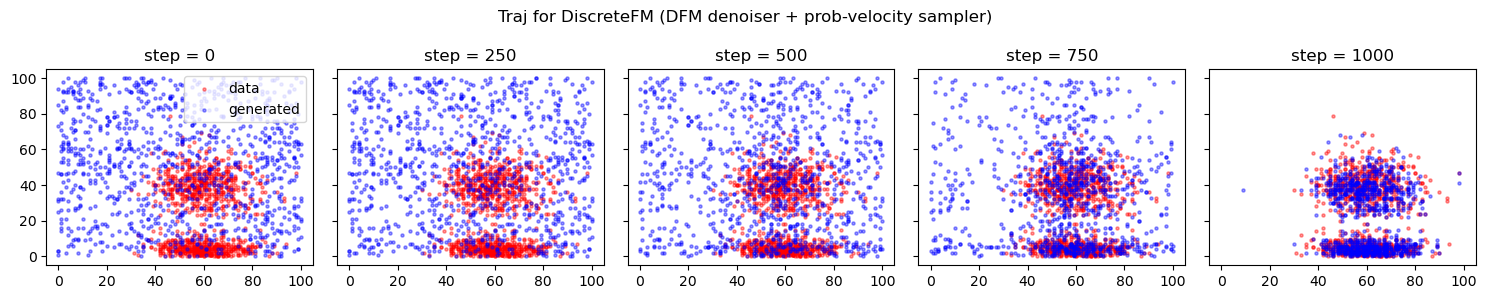

In [39]:
k = 5
T = traj_DisFM_np.shape[0] - 1
snapshot_ids = np.linspace(0, T, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)
for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1], c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_DisFM_np[t_idx, :, 0], traj_DisFM_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated')
    ax.set_title(f"step = {t_idx}")
    if j == 0:
        ax.legend(loc="best")
plt.suptitle("Traj for DiscreteFM (DFM denoiser + prob-velocity sampler)")
plt.tight_layout()
plt.show()

**The Poisson jump starts exactly from 0, so not sure if the trace is comparable to other methods**.

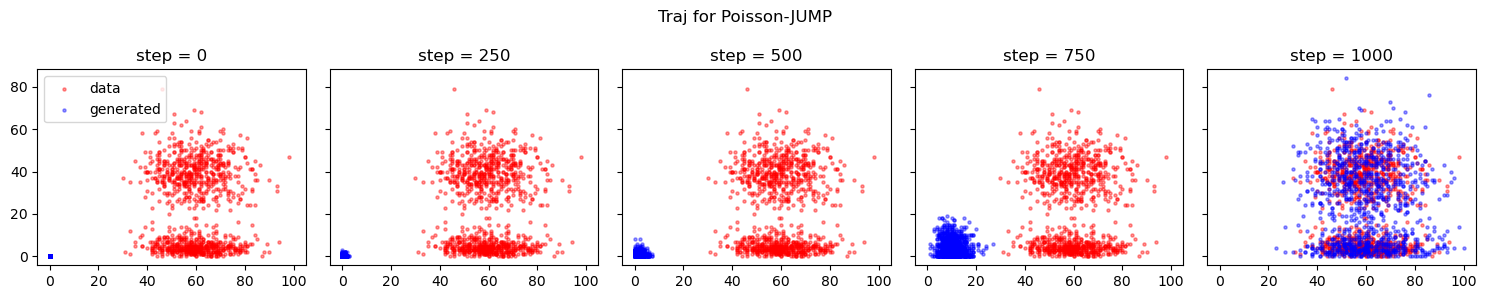

In [46]:
k = 5
T = traj_PJUMP_np.shape[0] - 1
snapshot_ids = np.linspace(0, T, k, dtype=int)

fig, axes = plt.subplots(1, k, figsize=(3 * k, 3), sharex=True, sharey=True)
for j, t_idx in enumerate(snapshot_ids):
    ax = axes[j]
    ax.scatter(X1[:, 0], X1[:, 1], c='r', s=5, alpha=alpha_pt, label='data')
    ax.scatter(traj_PJUMP_np[t_idx, :, 0], traj_PJUMP_np[t_idx, :, 1],
               c='b', s=5, alpha=alpha_pt, label='generated')
    ax.set_title(f"step = {t_idx}")
    if j == 0:
        ax.legend(loc="best")
plt.suptitle("Traj for Poisson-JUMP")
plt.tight_layout()
plt.show()